# DEFCom 2014 data EDA

some exploration

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, "/Users/lin_/Solar_Prediction")

from src.helper.data_preprocessing import GEFComTask15, NWP_VARS, ACCUM_VARS
from src.helper.features import FeatureBuilder

## Data Description

**Target variable:** solar power — normalized PV generation, range `[0, 1]`.

**Features:** 12 meteorological variables from the ECMWF numerical weather prediction (NWP) output. Original codes look like `NNN.128`; in the data tables they map to columns `VARNNN` (e.g. `169.128` → `VAR169`).

Below they are grouped by their physical effect on power generation, with units and meaning.

### Radiation — the most direct physical driver
| Column | Short | Meaning | Unit |
|---|---|---|---|
| `VAR169` | **SSRD** | Surface solar radiation downwards 太阳光穿过大气、云层之后，真正照到地面的太阳能总量 | J/m² (accumulated) |
| `VAR178` | **TSR** | Top net solar radiation | J/m² (accumulated) |
| `VAR175` | **STRD** | Surface thermal radiation downwards 大气、云、水汽等以热辐射形式向地面释放的能量 | J/m² (accumulated) |

### Cloud / moisture — how much sunlight is blocked
| Column | Short | Meaning | Unit |
|---|---|---|---|
| `VAR164` | **TCC** | Total cloud cover | 0–1 |
| `VAR78` | **tclw** | Total column liquid water 就是从地面往上到大气顶部，把这一整根“空气柱”里所有 液态云水 加起来。| kg/m² |
| `VAR79` | **tciw** | Total column ice water | kg/m² |
| `VAR157` | **r** | Relative humidity at 1000 mbar | % |

### Temperature / pressure — panel efficiency & weather state
| Column | Short | Meaning | Unit |
|---|---|---|---|
| `VAR167` | **2T** | 2 metre temperature | K (Kelvin) |
| `VAR134` | **SP** | Surface pressure | Pa |

### Wind / precipitation
| Column | Short | Meaning | Unit |
|---|---|---|---|
| `VAR165` | **10u** | 10 m U wind component (east–west) 10u > 0	west → east | m/s |
| `VAR166` | **10v** | 10 m V wind component (north–south) 10v > 0	south → north| m/s |
| `VAR228` | **TP** | Total precipitation (convective + stratiform) | m (accumulated) |

wind speed: $ \sqrt{10u^2+10v^2}$

CP = convective precipitation，对流性降水，比如雷阵雨；

LSP = large-scale / stratiform precipitation，大尺度层状降水，比如持续性阴雨。

###  Accumulated fields
The 4 variables marked **"accumulated"** — **SSRD (169), STRD (175), TSR (178), TP (228)** — are **not instantaneous values**. They accumulate from the forecast start time and **reset** periodically.



In [10]:
# Assemble the clean Task-15 table (train + solution + predictors, de-accumulated),
# then add features (local time, cyclic encodings, wind speed).
ds = GEFComTask15().load().deaccumulate()
zones = ds.per_zone()
df = ds.combined                                  # clean base table: raw + *_dea columns
fdf = FeatureBuilder(df).add_all().build()        # base + engineered features

for z, d in zones.items():
    print(f"Zone {z}: {len(d):>6} rows | {d.ts.min()} -> {d.ts.max()}")
print("Combined:", df.shape, "| with features:", fdf.shape)
df.head()

Zone 1:  19704 rows | 2012-04-01 01:00:00 -> 2014-07-01 00:00:00
Zone 2:  19704 rows | 2012-04-01 01:00:00 -> 2014-07-01 00:00:00
Zone 3:  19704 rows | 2012-04-01 01:00:00 -> 2014-07-01 00:00:00
Combined: (59112, 19) | with features: (59112, 29)


,ts,ZONE,POWER,VAR78,VAR79,VAR134,VAR157,VAR164,VAR165,VAR166,VAR167,VAR169,VAR175,VAR178,VAR228,VAR169_dea,VAR175_dea,VAR178_dea,VAR228_dea
0,2012-04-01 01:00:00,1,0.754103,0.001967,0.003609,94843.6250,60.221909,0.244601,1.039334,-2.503039,294.448486,2577830.0,1202532.0,2861797.0,0.000000,2577830.0,1202532.0,2861797.0,0.000000
1,2012-04-01 02:00:00,1,0.555000,0.005524,0.033575,94757.9375,54.678604,0.457138,2.482865,-2.993330,295.651367,5356093.0,2446757.0,5949378.0,0.000000,2778263.0,1244225.0,3087581.0,0.000000
2,2012-04-01 03:00:00,1,0.438397,0.030113,0.132009,94732.8125,61.294891,0.771429,3.339867,-1.982535,294.454590,7921788.0,3681336.0,8939176.0,0.001341,2565695.0,1234579.0,2989798.0,0.001341
3,2012-04-01 04:00:00,1,0.145449,0.057167,0.110645,94704.0625,67.775284,0.965866,3.106102,-1.446051,293.261475,9860520.0,4921504.0,11331679.0,0.002501,1938732.0,1240168.0,2392503.0,0.001161
4,2012-04-01 05:00:00,1,0.111987,0.051027,0.189560,94675.0000,70.172989,0.944669,2.601146,-1.904493,292.732910,11143097.0,6254380.0,13105558.0,0.003331,1282577.0,1332876.0,1773879.0,0.000830


## Data quality check
Missing values, target range (`POWER ∈ [0,1]`), duplicate timestamps, and hourly continuity.

In [11]:
# Missing values, POWER range, duplicate timestamps & hourly gaps
print("Missing values:", int(df.isna().sum().sum()))
print("POWER min/max :", round(df.POWER.min(), 3), round(df.POWER.max(), 3),
      "| outside [0,1]:", int(((df.POWER < 0) | (df.POWER > 1)).sum()))

for z, d in zones.items():
    dup  = int(d.ts.duplicated().sum())
    gaps = int((d.ts.diff().dropna() != pd.Timedelta("1h")).sum())
    print(f"Zone {z}: dup_ts={dup} | non-1h gaps={gaps}")


Missing values: 0
POWER min/max : 0.0 1.004 | outside [0,1]: 1
Zone 1: dup_ts=0 | non-1h gaps=0
Zone 2: dup_ts=0 | non-1h gaps=0
Zone 3: dup_ts=0 | non-1h gaps=0


In [12]:
# The old assembled file had ~1683 hourly gaps; the Task-15 rebuild is continuous,
# so the only quality note left is one POWER value that slightly exceeds 1.
over = df[df.POWER > 1][["ts", "ZONE", "POWER"]]
print("rows with POWER > 1 (sensor overshoot, clip to [0,1] downstream):", len(over))
print(over.to_string(index=False))

rows with POWER > 1 (sensor overshoot, clip to [0,1] downstream): 1
                 ts  ZONE   POWER
2013-11-04 02:00:00     3 1.00355


## Local time & de-accumulation

Timestamps are UTC; the plant is at UTC+10 (local time = UTC + `tz_offset`). Aligning to
local time shows the expected diurnal cycle — power peaks at midday and is zero at night.
The four accumulated NWP fields are de-accumulated into true hourly values (`*_dea`).

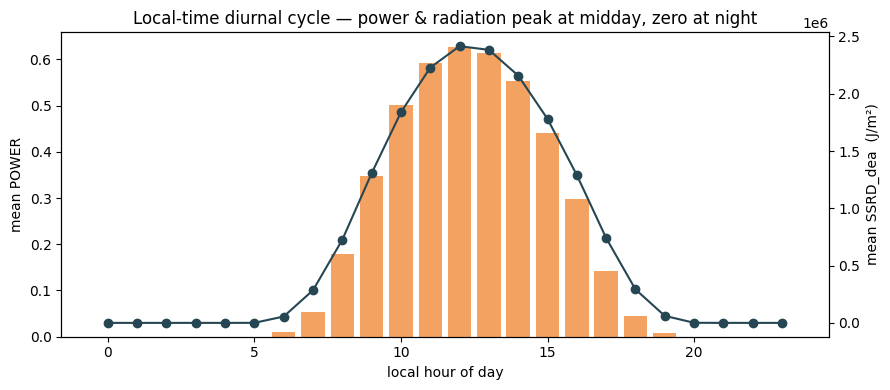

In [13]:
# Diurnal cycle in LOCAL time: mean POWER and mean hourly SSRD by local hour of day.
g = fdf.groupby("hour").agg(power=("POWER", "mean"), ssrd=("VAR169_dea", "mean"))

fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.bar(g.index, g.power, color="#f4a261", label="mean POWER")
ax1.set_xlabel("local hour of day"); ax1.set_ylabel("mean POWER")
ax2 = ax1.twinx()
ax2.plot(g.index, g.ssrd, color="#264653", marker="o", label="mean SSRD (hourly)")
ax2.set_ylabel("mean SSRD_dea  (J/m²)")
ax1.set_title("Local-time diurnal cycle — power & radiation peak at midday, zero at night")
plt.tight_layout(); plt.show()

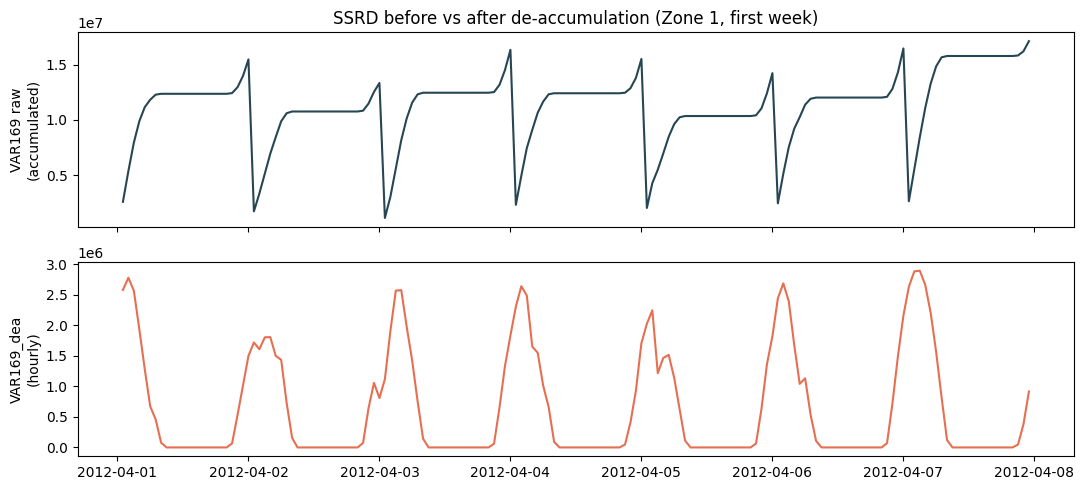

In [14]:
# De-accumulation check: raw SSRD ramps up over the day and resets at 01:00;
# VAR169_dea recovers the true hourly value. Shown for Zone 1, first week.
z1 = fdf[(fdf.ZONE == 1) & (fdf.ts < "2012-04-08")]

fig, ax = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
ax[0].plot(z1.ts, z1.VAR169, color="#264653")
ax[0].set_ylabel("VAR169 raw\n(accumulated)")
ax[0].set_title("SSRD before vs after de-accumulation (Zone 1, first week)")
ax[1].plot(z1.ts, z1.VAR169_dea, color="#e76f51")
ax[1].set_ylabel("VAR169_dea\n(hourly)")
plt.tight_layout(); plt.show()

## Daytime vs full-day accuracy

Night power is trivially 0, so scoring those hours inflates accuracy. Below, a simple
per-(zone, hour) climatology baseline is scored both ways to show the gap; the day-ahead
monthly accuracy (`1 - RMSE/Cap`, `1 - MAE/Cap`) is computed on daytime points only.

In [15]:
from src.helper import metrics as M

print("daytime fraction:", round(fdf.is_daytime.mean(), 3))

# Climatology baseline: predict mean POWER per (zone, local hour). Illustrative (in-sample).
clim = fdf.groupby(["ZONE", "hour"]).POWER.mean().rename("y_pred")
ev = fdf.merge(clim, on=["ZONE", "hour"]).rename(columns={"POWER": "y_true"})
day = ev[ev.is_daytime]

print("full-day  1-RMSE:", round(M.accuracy_rmse(ev.y_true, ev.y_pred), 4))
print("daytime   1-RMSE:", round(M.accuracy_rmse(day.y_true, day.y_pred), 4))

# Day-ahead monthly-average accuracy (daytime only), averaged over zones
M.monthly_accuracy(ev, cap=1.0).groupby("month").mean().round(3)

daytime fraction: 0.535
full-day  1-RMSE: 0.8695
daytime   1-RMSE: 0.822


,acc_rmse,acc_mae
month,,
2012-04,0.836,0.869
2012-05,0.875,0.898
2012-06,0.811,0.840
2012-07,0.857,0.883
2012-08,0.857,0.882
2012-09,0.829,0.861
2012-10,0.819,0.857
2012-11,0.835,0.871
2012-12,0.838,0.877


## Save clean table & walk-forward split preview

Save the clean base table (raw + de-accumulated, no features) to `data/process`, then
preview the expanding walk-forward folds that mirror the GEFCom monthly rolling tasks.

In [16]:
from src.helper.backtest import WalkForward

# Save the clean base table
path = ds.to_processed()
print("saved:", path)

# Expanding walk-forward plan: one calendar month per test fold (mirrors GEFCom tasks)
WalkForward.gefcom_monthly().summary(fdf)

saved: /Users/lin_/Solar_Prediction/data/process/gefcom_task15_clean.parquet


,fold,train_start,train_end,test_start,test_end,n_train,n_test
0,0,2012-04-01 01:00:00,2013-05-01 01:00:00,2013-05-01 01:00:00,2013-06-01 01:00:00,28440,2232
1,1,2012-04-01 01:00:00,2013-06-01 01:00:00,2013-06-01 01:00:00,2013-07-01 01:00:00,30672,2160
2,2,2012-04-01 01:00:00,2013-07-01 01:00:00,2013-07-01 01:00:00,2013-08-01 01:00:00,32832,2232
3,3,2012-04-01 01:00:00,2013-08-01 01:00:00,2013-08-01 01:00:00,2013-09-01 01:00:00,35064,2232
4,4,2012-04-01 01:00:00,2013-09-01 01:00:00,2013-09-01 01:00:00,2013-10-01 01:00:00,37296,2160
5,5,2012-04-01 01:00:00,2013-10-01 01:00:00,2013-10-01 01:00:00,2013-11-01 01:00:00,39456,2232
6,6,2012-04-01 01:00:00,2013-11-01 01:00:00,2013-11-01 01:00:00,2013-12-01 01:00:00,41688,2160
7,7,2012-04-01 01:00:00,2013-12-01 01:00:00,2013-12-01 01:00:00,2014-01-01 01:00:00,43848,2232
8,8,2012-04-01 01:00:00,2014-01-01 01:00:00,2014-01-01 01:00:00,2014-02-01 01:00:00,46080,2232
9,9,2012-04-01 01:00:00,2014-02-01 01:00:00,2014-02-01 01:00:00,2014-03-01 01:00:00,48312,2016
